In [2]:
import os
import json

KAGGLE_USERNAME = "aeshikasingh"   # ← paste your username
KAGGLE_KEY      = "KGAT_7b814d12b10610ecfac4347a036f0425"    # ← paste your key

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

kaggle_creds = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Install required packages
!pip install -q kaggle grad-cam streamlit pyngrok

print("Kaggle API configured successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 121.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 127.1 MB/s eta 0:00:00
Kaggle API configured successfully!


In [3]:
import os

DATA_ROOT = "/content/brisc2025"

# Download and unzip the BRISC 2025 dataset
print("Downloading BRISC 2025 dataset from Kaggle...")
!kaggle datasets download -d briscdataset/brisc2025 -p /content/ --unzip

# Verify the folder structure
print("\nDataset structure:")
for root, dirs, files in os.walk("/content/brisc2025"):
    level = root.replace("/content/brisc2025", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        subindent = "  " * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")

print("\n Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025
License(s): Attribution 4.0 International (CC BY 4.0)
100% 250M/250M [00:02<00:00, 93.4MB/s]


Dataset structure:
brisc2025/
  manifest.json.sha256
  manifest.csv
  manifest.json
  classification_task/
    train/
      meningioma/
      glioma/
      pituitary/
      no_tumor/
    test/
      meningioma/
      glioma/
      pituitary/
      no_tumor/
  segmentation_task/
    train/
      images/
      masks/
    test/
      images/
      masks/

 Dataset downloaded!


In [4]:
import os

CLASSIFICATION_DIR = "/content/brisc2025/classification_task"

DATA_DIR = os.path.join(CLASSIFICATION_DIR, "train")

print("Class Distribution:")
total = 0
for folder in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(path):
        count = len(os.listdir(path))
        total += count
        print(f"  {folder:15s}: {count} images")

print(f"  {'TOTAL':15s}: {total} images")

Class Distribution:
  glioma         : 1147 images
  meningioma     : 1329 images
  no_tumor       : 1067 images
  pituitary      : 1457 images
  TOTAL          : 5000 images


In [5]:
import os, time, copy
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

#  HYPERPARAMETERS

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20       # Stage 2 fine-tuning epochs
LR          = 1e-5     # Fine-tuning learning rate
WEIGHT_DECAY= 1e-4
SEED        = 42
NUM_WORKERS = 2
PATIENCE    = 8        # Early stopping patience
OUTPUT_DIR  = "/content/outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("   GPU:", torch.cuda.get_device_name(0))

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Config ready")

Using device: cuda
   GPU: Tesla T4
Config ready


In [6]:
import cv2
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms
import torch
import os
from tqdm import tqdm

TRAIN_DIR = os.path.join(DATA_ROOT, "classification_task", "train")
TEST_DIR  = os.path.join(DATA_ROOT, "classification_task", "test")


def apply_clahe(image):
    img_array = np.array(image.convert("L"))
    clahe     = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced  = clahe.apply(img_array)
    return Image.fromarray(enhanced).convert("RGB")

CLAHE_TRAIN_DIR = "/content/brisc2025_clahe/train"
CLAHE_TEST_DIR  = "/content/brisc2025_clahe/test"

for src_dir, dst_dir in [(TRAIN_DIR, CLAHE_TRAIN_DIR),
                          (TEST_DIR,  CLAHE_TEST_DIR)]:
    if not os.path.exists(dst_dir):
        print(f"Applying CLAHE: {src_dir} ...")
        for class_folder in os.listdir(src_dir):
            src_class = os.path.join(src_dir, class_folder)
            dst_class = os.path.join(dst_dir, class_folder)
            os.makedirs(dst_class, exist_ok=True)
            for fname in tqdm(os.listdir(src_class), desc=class_folder):
                src_path = os.path.join(src_class, fname)
                dst_path = os.path.join(dst_class, fname)
                img = Image.open(src_path).convert("RGB")
                img = apply_clahe(img)
                img.save(dst_path)
        print(f" Done: {dst_dir}")
    else:
        print(f" Already exists — skipping: {dst_dir}")


TRAIN_DIR = CLAHE_TRAIN_DIR
TEST_DIR  = CLAHE_TEST_DIR


#  TRANSFORMS

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

inference_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

full_train_dataset = datasets.ImageFolder(TRAIN_DIR)
test_dataset_raw   = datasets.ImageFolder(TEST_DIR)

class_names = full_train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes  :", class_names)
print("Train+Val:", len(full_train_dataset))
print("Test     :", len(test_dataset_raw))

targets = [s[1] for s in full_train_dataset.samples]

# 80% train | 20% val — stratified split from official train set
train_idx, val_idx = train_test_split(
    np.arange(len(full_train_dataset)),
    test_size=0.20,
    stratify=targets,
    random_state=SEED
)

print(f"\nSplit — Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_dataset_raw)}")

class CustomImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

train_samples = [full_train_dataset.samples[i] for i in train_idx]
val_samples   = [full_train_dataset.samples[i] for i in val_idx]

train_dataset = CustomImageDataset(train_samples, transform=train_tfms)
val_dataset   = CustomImageDataset(val_samples,   transform=inference_tfms)
test_dataset  = CustomImageDataset(
    test_dataset_raw.samples, transform=inference_tfms
)

#  CLASS WEIGHTS & WEIGHTED SAMPLER

train_labels  = [targets[i] for i in train_idx]
class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / (class_counts + 1e-6)

print("\n Train class distribution:")
for name, count in zip(class_names, class_counts):
    print(f"  {name:15s}: {count}")

print("\n Val class distribution:")
val_labels = [targets[i] for i in val_idx]
val_counts = np.bincount(val_labels, minlength=NUM_CLASSES)
for name, count in zip(class_names, val_counts):
    print(f"  {name:15s}: {count}")

print("\n Test class distribution:")
test_labels = [s[1] for s in test_dataset_raw.samples]
test_counts = np.bincount(test_labels, minlength=NUM_CLASSES)
for name, count in zip(class_names, test_counts):
    print(f"  {name:15s}: {count}")

sample_weights = torch.DoubleTensor([class_weights[t] for t in train_labels])
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2)

print("\n DataLoaders ready — official BRISC 2025 split + CLAHE")

Applying CLAHE: /content/brisc2025/classification_task/train ...


no_tumor: 100%|██████████| 1067/1067 [00:03<00:00, 279.80it/s]


 Done: /content/brisc2025_clahe/train
Applying CLAHE: /content/brisc2025/classification_task/test ...


no_tumor: 100%|██████████| 140/140 [00:00<00:00, 330.70it/s]

 Done: /content/brisc2025_clahe/test
Classes  : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train+Val: 5000
Test     : 1000

Split — Train: 4000 | Val: 1000 | Test: 1000

 Train class distribution:
  glioma         : 918
  meningioma     : 1063
  no_tumor       : 854
  pituitary      : 1165

 Val class distribution:
  glioma         : 229
  meningioma     : 266
  no_tumor       : 213
  pituitary      : 292

 Test class distribution:
  glioma         : 254
  meningioma     : 306
  no_tumor       : 140
  pituitary      : 300

 DataLoaders ready — official BRISC 2025 split + CLAHE


In [7]:

#  BUILD MODEL

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in model.parameters():
    param.requires_grad = False

# Replace final FC with a custom classifier head
in_features = model.fc.in_features  # 2048 for ResNet50
model.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

# Weighted loss to further combat class imbalance
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device)
)

print(f"   ResNet50 loaded with ImageNet weights")
print(f"   Backbone: FROZEN | FC head: 2048 → 512 → {NUM_CLASSES}")
print(f"   Total params   : {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 146MB/s]


   ResNet50 loaded with ImageNet weights
   Backbone: FROZEN | FC head: 2048 → 512 → 4
   Total params   : 24,559,172
   Trainable params: 1,051,140


In [8]:

optimizer_warmup = optim.Adam(model.fc.parameters(), lr=1e-3)

print("===== STAGE 1: Warming up FC head (3 epochs) =====")

for epoch in range(3):
    model.train()
    correct, total, loss_total = 0, 0, 0.0

    for imgs, labels in tqdm(train_loader, desc=f"Warmup Epoch {epoch+1}/3"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_warmup.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_warmup.step()

        loss_total += loss.item()
        preds      = torch.argmax(outputs, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    train_acc = correct / total


    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = torch.argmax(model(imgs), dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    print(f"  Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {loss_total/len(train_loader):.4f}")

print("\n Stage 1 complete — FC head warmed up")

===== STAGE 1: Warming up FC head (3 epochs) =====


Warmup Epoch 1/3: 100%|██████████| 125/125 [00:32<00:00,  3.85it/s]


  Epoch 1 | Train Acc: 0.7110 | Val Acc: 0.8440 | Loss: 0.7317


Warmup Epoch 2/3: 100%|██████████| 125/125 [00:28<00:00,  4.37it/s]


  Epoch 2 | Train Acc: 0.7935 | Val Acc: 0.8220 | Loss: 0.5280


Warmup Epoch 3/3: 100%|██████████| 125/125 [00:27<00:00,  4.52it/s]


  Epoch 3 | Train Acc: 0.8353 | Val Acc: 0.8650 | Loss: 0.4278

 Stage 1 complete — FC head warmed up


In [9]:
# Unfreeze ALL layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

best_auc   = 0.0
trigger    = 0
best_state = None


history = {"train_acc": [], "val_acc": [], "val_auc": []}

print("===== STAGE 2: Fine-tuning entire ResNet50 =====")
print(f"Epochs: {NUM_EPOCHS} | LR: {LR} | Patience: {PATIENCE}\n")

for epoch in range(NUM_EPOCHS):
    print(f"── Epoch {epoch+1}/{NUM_EPOCHS} ──")

    # ── TRAIN ──
    model.train()
    correct, total = 0, 0

    for imgs, labels in tqdm(train_loader, desc="  Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        preds    = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total

    # ── VALIDATE ──
    model.eval()
    correct, total = 0, 0
    all_probs, all_targets = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc="  Val"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1).cpu().numpy()
            preds   = np.argmax(probs, axis=1)

            all_probs.append(probs)
            all_targets.append(labels.cpu().numpy())

            correct += (preds == labels.cpu().numpy()).sum()
            total   += imgs.size(0)

    val_acc      = correct / total
    all_probs    = np.vstack(all_probs)
    all_targets  = np.concatenate(all_targets)

    try:
        val_auc = roc_auc_score(all_targets, all_probs, multi_class="ovr")
    except Exception:
        val_auc = 0.0

    scheduler.step()

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | LR: {current_lr:.2e}")

    # Save best model by AUC
    if val_auc > best_auc:
        best_auc   = val_auc
        trigger    = 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, os.path.join(OUTPUT_DIR, "best_brain_tumor_model.pth"))
        print(f"  Best model saved (AUC: {best_auc:.4f})")
    else:
        trigger += 1
        print(f"  No improvement ({trigger}/{PATIENCE})")

    if trigger >= PATIENCE:
        print("\n Early stopping triggered")
        break

print(f"\n Training complete | Best Val AUC: {best_auc:.4f}")

===== STAGE 2: Fine-tuning entire ResNet50 =====
Epochs: 20 | LR: 1e-05 | Patience: 8

── Epoch 1/20 ──


  Val: 100%|██████████| 32/32 [00:05<00:00,  6.33it/s]


  Train Acc: 0.8935 | Val Acc: 0.8880 | Val AUC: 0.9838 | LR: 9.94e-06
  Best model saved (AUC: 0.9838)
── Epoch 2/20 ──


  Val: 100%|██████████| 32/32 [00:05<00:00,  6.22it/s]


  Train Acc: 0.9333 | Val Acc: 0.9070 | Val AUC: 0.9880 | LR: 9.76e-06
  Best model saved (AUC: 0.9880)
── Epoch 3/20 ──


...

  Train Acc: 0.9910 | Val Acc: 0.9520 | Val AUC: 0.9967 | LR: 2.45e-07
  Best model saved (AUC: 0.9967)
── Epoch 19/20 ──


  Val: 100%|██████████| 32/32 [00:05<00:00,  5.65it/s]


  Train Acc: 0.9910 | Val Acc: 0.9490 | Val AUC: 0.9966 | LR: 6.16e-08
  No improvement (1/8)
── Epoch 20/20 ──


  Val: 100%|██████████| 32/32 [00:06<00:00,  5.31it/s]


  Train Acc: 0.9915 | Val Acc: 0.9550 | Val AUC: 0.9960 | LR: 0.00e+00
  No improvement (2/8)

 Training complete | Best Val AUC: 0.9967


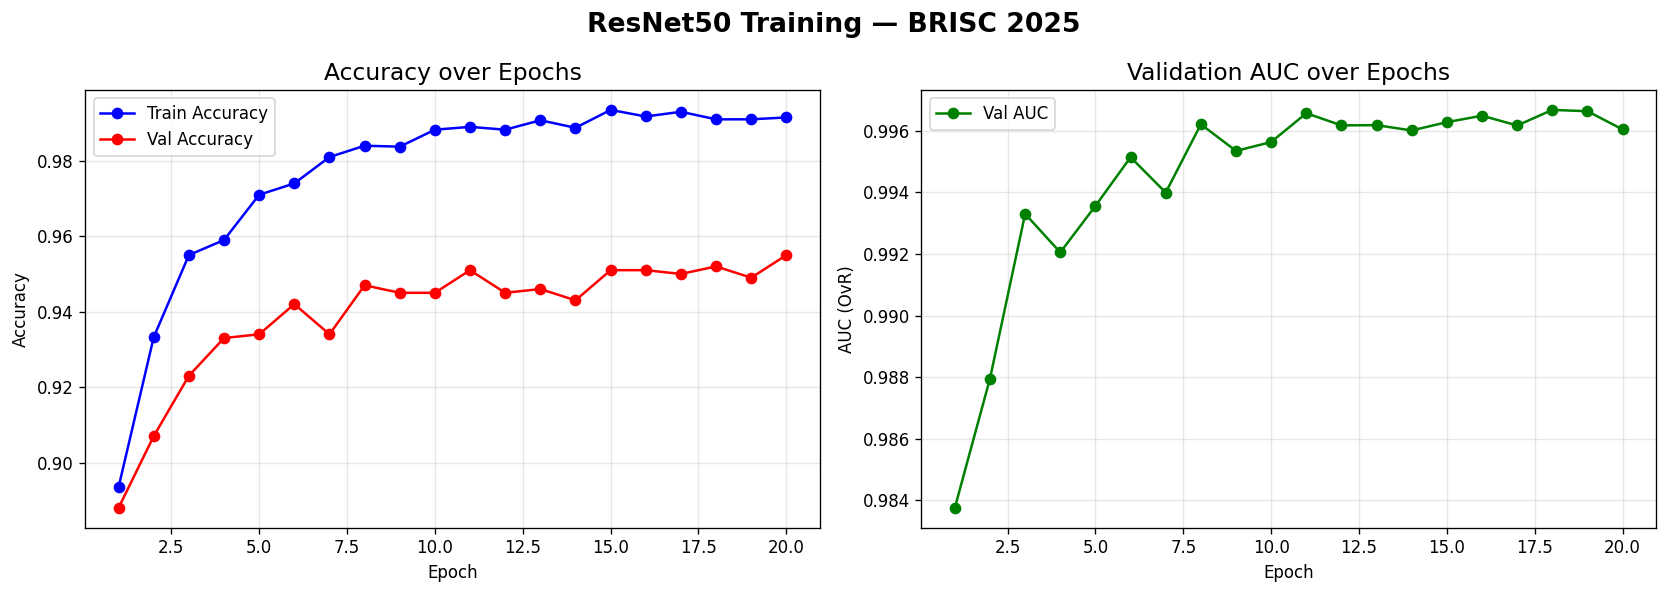

Training curves saved


In [10]:
epochs_ran = range(1, len(history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_ran, history["train_acc"], "b-o", label="Train Accuracy")
axes[0].plot(epochs_ran, history["val_acc"],   "r-o", label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history["val_auc"], "g-o", label="Val AUC")
axes[1].set_title("Validation AUC over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC (OvR)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ResNet50 Training — BRISC 2025", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), bbox_inches="tight")
plt.show()
print("Training curves saved")

Evaluating on Test Set: 100%|██████████| 32/32 [00:05<00:00,  6.10it/s]


  FINAL TEST ACCURACY : 0.9270 (92.70%)
  FINAL TEST AUC (OvR): 0.9953

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma     0.9856    0.8110    0.8898       254
  meningioma     0.8899    0.9248    0.9071       306
    no_tumor     0.9517    0.9857    0.9684       140
   pituitary     0.9146    1.0000    0.9554       300

    accuracy                         0.9270      1000
   macro avg     0.9355    0.9304    0.9302      1000
weighted avg     0.9303    0.9270    0.9258      1000



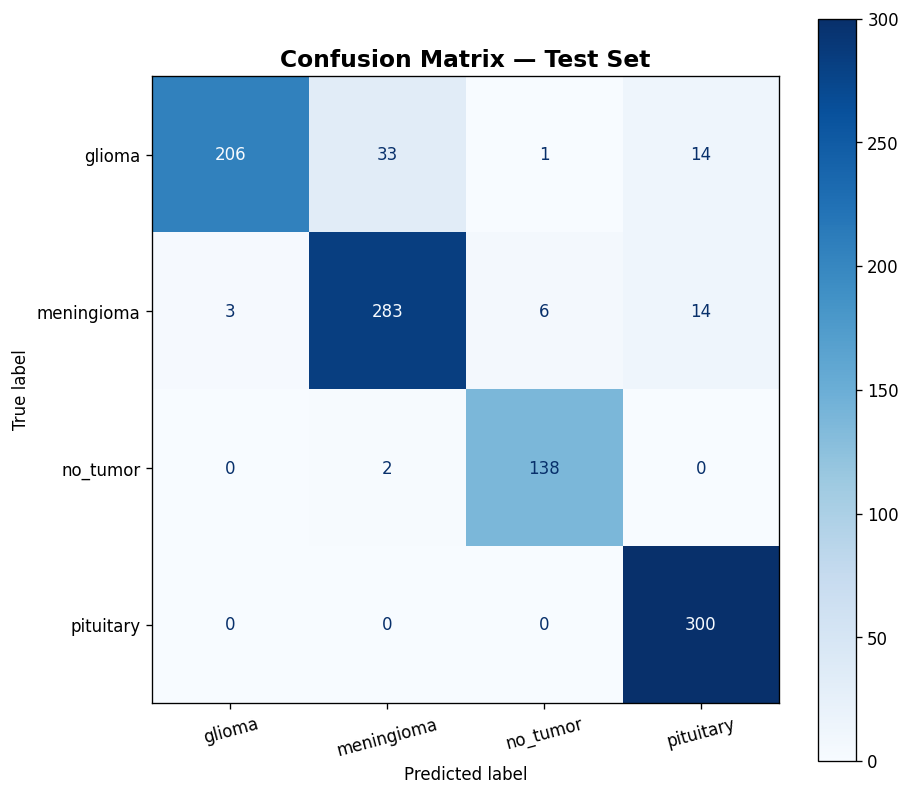

Confusion matrix saved


In [11]:
# Load best saved model
model.load_state_dict(best_state)
model.eval()

all_preds       = []
all_labels      = []
all_probs_test  = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        imgs   = imgs.to(device)
        outputs = model(imgs)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = np.argmax(probs, axis=1)

        all_probs_test.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs_test = np.array(all_probs_test)
all_preds      = np.array(all_preds)
all_labels     = np.array(all_labels)

# ── METRICS ──
test_acc = np.mean(all_preds == all_labels)


try:
    test_auc = roc_auc_score(all_labels, all_probs_test, multi_class="ovr")
except Exception as e:
    test_auc = 0.0
    print(f"AUC error: {e}")

print("=" * 50)
print(f"  FINAL TEST ACCURACY : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  FINAL TEST AUC (OvR): {test_auc:.4f}")
print("=" * 50)

print("\nCLASSIFICATION REPORT:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# ── CONFUSION MATRIX ──
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), bbox_inches="tight")
plt.show()
print("Confusion matrix saved")

In [12]:
def predict_image(image_path):
    """
    Predict tumor type from an MRI image path.
    Returns predicted class and per-class confidence scores.
    FIX: uses inference_tfms (consistent with val/test transforms)
    """
    image        = Image.open(image_path).convert("RGB")
    input_tensor = inference_tfms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probs   = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_class       = np.argmax(probs)
    predicted_label  = class_names[pred_class]
    confidence_score = probs[pred_class]

    # Plot image + bar chart of confidence scores
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(image)
    axes[0].set_title(
        f"Prediction: {predicted_label.upper()}\nConfidence: {confidence_score:.2%}",
        fontsize=13, fontweight="bold"
    )
    axes[0].axis("off")

    colors = ["#e74c3c" if i == pred_class else "#3498db" for i in range(NUM_CLASSES)]
    axes[1].barh(class_names, probs * 100, color=colors)
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Class Probabilities", fontsize=13)
    axes[1].set_xlim(0, 100)
    for i, v in enumerate(probs):
        axes[1].text(v * 100 + 1, i, f"{v:.2%}", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

    print(f"\nPredicted Tumor : {predicted_label}")
    print(f"Confidence      : {confidence_score:.4f}")
    for name, prob in zip(class_names, probs):
        print(f"  {name:15s}: {prob:.4f}")

    return predicted_label, confidence_score, probs

print("predict_image() function ready")
print("Usage: predict_image('your_mri_scan.jpg')")

predict_image() function ready
Usage: predict_image('your_mri_scan.jpg')


In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

def generate_gradcam(image_path):
    """
    Generate Grad-CAM heatmap for an MRI image.
    FIX: removed torch.no_grad() block before cam() call —
         Grad-CAM needs gradient flow to work correctly.
    """
    # Load and prepare image
    image         = cv2.imread(image_path)
    image_rgb     = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image_rgb, (IMG_SIZE, IMG_SIZE))
    rgb_img_float = image_resized.astype(np.float32) / 255.0

    # Prepare input tensor using inference transforms
    input_tensor = inference_tfms(
        Image.fromarray(image_resized)
    ).unsqueeze(0).to(device)

    # Target the last convolutional block of ResNet50
    target_layers = [model.layer4[-1]]

    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Get prediction for title
    with torch.no_grad():
        outputs    = model(input_tensor)
        probs      = torch.softmax(outputs, dim=1)[0].cpu().numpy()
        pred_class = np.argmax(probs)

    # Overlay heatmap on image
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    # Plot: Original | Heatmap | Overlay
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_resized)
    axes[0].set_title("Original MRI", fontsize=13)
    axes[0].axis("off")

    im = axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap", fontsize=13)
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(visualization)
    axes[2].set_title(
        f"Overlay\nPrediction: {class_names[pred_class]} ({probs[pred_class]:.2%})",
        fontsize=13
    )
    axes[2].axis("off")

    plt.suptitle("Grad-CAM Visualization — Brain Tumor MRI", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "gradcam_output.png"), bbox_inches="tight")
    plt.show()

    print(f"Predicted Tumor : {class_names[pred_class]}")
    print(f"Confidence      : {probs[pred_class]:.4f}")

print("generate_gradcam() function ready")
print("Usage: generate_gradcam('your_mri_scan.jpg')")

generate_gradcam() function ready
Usage: generate_gradcam('your_mri_scan.jpg')


Upload an MRI image to test...


Saving 46 no.jpg to 46 no.jpg


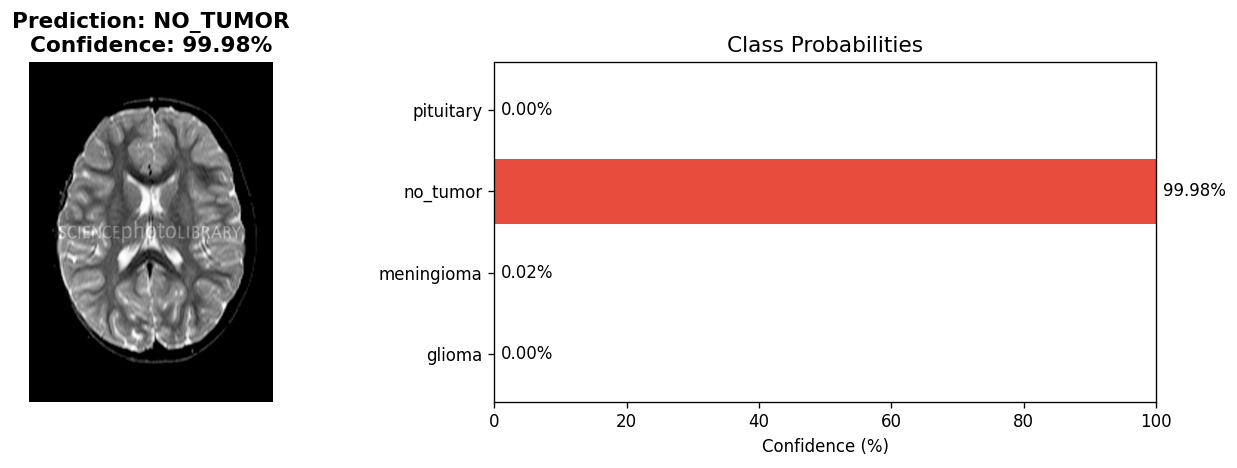


Predicted Tumor : no_tumor
Confidence      : 0.9998
  glioma         : 0.0000
  meningioma     : 0.0002
  no_tumor       : 0.9998
  pituitary      : 0.0000

──────────────────────────────────────────────────



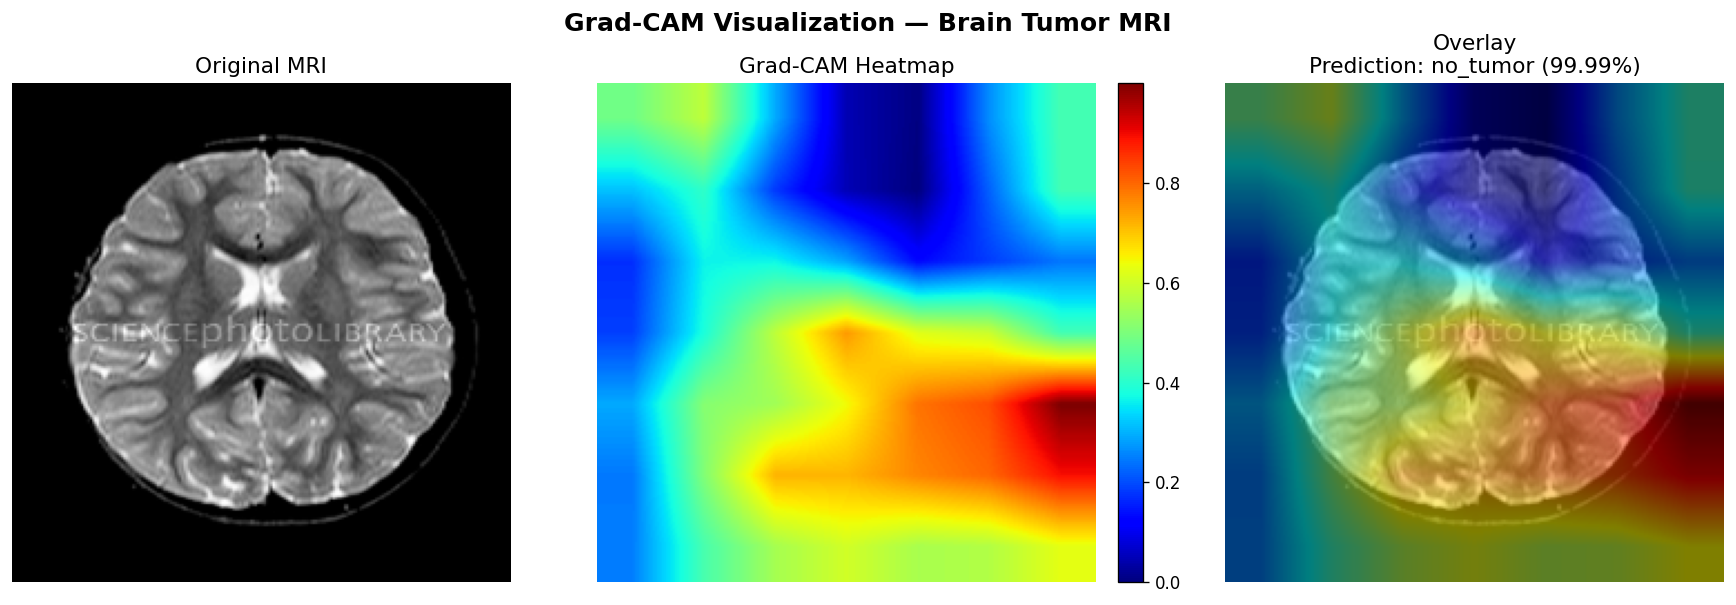

Predicted Tumor : no_tumor
Confidence      : 0.9999


In [14]:
# Upload your own image
from google.colab import files
print("Upload an MRI image to test...")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Run prediction
predict_image(image_path)

print("\n" + "─"*50 + "\n")

# Run Grad-CAM
generate_gradcam(image_path)

In [15]:
# Save final model weights
final_model_path = os.path.join(OUTPUT_DIR, "final_brain_tumor_model.pth")
torch.save(model.state_dict(), final_model_path)
print(f" Final model saved to: {final_model_path}")

# Download model to local machine
from google.colab import files
files.download(final_model_path)
print(" Model download started")

 Final model saved to: /content/outputs/final_brain_tumor_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Model download started


In [ ]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

MODEL_PATH  = "/content/outputs/final_brain_tumor_model.pth"
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
NUM_CLASSES = len(class_names)
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@st.cache_resource
def load_model():
    m = models.resnet50(weights=None)
    m.fc = nn.Sequential(
        nn.Linear(m.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, NUM_CLASSES)
    )
    m.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    m.to(device).eval()
    return m

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

st.set_page_config(page_title="Brain Tumor Classifier", page_icon="🧠", layout="wide")
st.title("🧠 Brain Tumor Classification")
st.write("ResNet50 + Grad-CAM | Trained on BRISC 2025 Dataset")
st.divider()

model = load_model()
uploaded_file = st.file_uploader("Upload an MRI Image", type=["jpg", "png", "jpeg"])

if uploaded_file:
    image        = Image.open(uploaded_file).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probs   = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_class   = np.argmax(probs)
    pred_label   = class_names[pred_class]
    confidence   = probs[pred_class]

    col1, col2 = st.columns(2)
    with col1:
        st.image(image, caption="Uploaded MRI", use_column_width=True)
        st.metric("Prediction", pred_label.upper())
        st.metric("Confidence", f"{confidence:.2%}")
        st.write("**All class probabilities:**")
        for name, prob in zip(class_names, probs):
            st.progress(float(prob), text=f"{name}: {prob:.2%}")

    with col2:
        image_np      = np.array(image.resize((224, 224))).astype(np.float32) / 255.0
        target_layers = [model.layer4[-1]]
        cam           = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor)[0]
        visualization = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)
        st.image(visualization, caption="Grad-CAM Explanation", use_column_width=True)
        st.caption("Red regions = areas most influential to the prediction")

In [ ]:
# Launch the Streamlit app (runs in background, accessible via public URL)
!streamlit run app.py &

# Use localtunnel for public URL
import time
time.sleep(3)
!npx localtunnel --port 8501